# Spring of Code - Artificial Intelligence

## Week 08: Deep Learning Applications

### Day 03: Custom Object Detection with YOLOv8 

Welcome! In this extremely detailed notebook, we are going to learn how to prepare, visualize, and train an **Object Detection** model on an entirely custom dataset: **Road Vehicle Images**.

While standard pre-trained models can detect generic classes like "car" or "person", our custom dataset contains highly specific regional vehicles such as *auto rickshaws*, *human haulers*, and *CNG three-wheelers*.

**Our Pipeline Today:**
1. **Dataset Logistics**: Programmatically download the Road Vehicle dataset and bring it into our workspace.
2. **YOLO Formatting**: Understand exactly how YOLO structures Image Data alongside Text Label annotations.
3. **Pre-Training Visualization**: Prove our data is correct by calculating coordinates and drawing ground-truth bounding boxes *before* we ever train a model.
4. **Custom Training Loop**: Invoke the Ultralytics engine to fine-tune a YOLOv8-nano variant perfectly onto our custom vehicles.
5. **Post-Training Inference**: Evaluate the resulting model on separate validation imagery and visualize the AI's predictions dynamically!

---
## 1. Setup and Installs
First, we will ensure that `kagglehub` is installed to fetch the data, along with `ultralytics` for our neural engine and `opencv-python` for graphics manipulation.

In [1]:
# !pip install kagglehub ultralytics opencv-python -q

import os
import shutil
import cv2
import yaml
import glob
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## 2. Acquiring the Dataset

The dataset is `ashfakyeafi/road-vehicle-images-dataset`. We will download it dynamically using Python and safely copy it into a `./vehicle_dataset` folder directly within our Notebooks folder so we can access it directly.

In [ ]:
import kagglehub

# print("Downloading Road Vehicle Dataset...")
cache_path = kagglehub.dataset_download("ashfakyeafi/road-vehicle-images-dataset")
# print("Dataset downloaded to cache:", cache_path)

dataset_dir = "./vehicle_dataset"

# Check if we already copied it here to prevent copying massive amounts of data repeatedly
# if not os.path.exists(dataset_dir):
#     print("Copying dataset locally... this may take a moment.")
shutil.copytree(cache_path, dataset_dir)
#     print("Copy Complete!")
# else:
#     print("Dataset already exists in local directory. Skipping copy.")
    
# Our actual data sits inside a subfolder named 'trafic_data'
trafic_dir = os.path.join(dataset_dir, "trafic_data")
print("\nContents of local dataset folder:", os.listdir(trafic_dir))

Dataset downloaded to cache: C:\Users\DIPLAB\.cache\kagglehub\datasets\ashfakyeafi\road-vehicle-images-dataset\versions\2
Copying dataset locally... this may take a moment.
Copy Complete!

Contents of local dataset folder: ['data_1.yaml', 'train', 'valid']


---
## 3. Formatting Custom Datasets for YOLO

If you look at the console output above, we have `train`, `valid`, and `data_1.yaml`.

### How YOLO Reads Annotations:
Inside the `train` folder, YOLO expects two subfolders: `images` (containing the JPEGs) and `labels` (containing identical `.txt` files with the same names).

A `.txt` label file contains rows formatted as: `class_id x_center y_center width height` (All values are normalized between 0.0 and 1.0).

### Re-Writing the YAML File for Absolute Paths
The `data_1.yaml` specifies the categories and locations of the training images. Because relative paths (`../train/images`) inside YAMLs can horribly break depending on where your terminal was launched from, we will read the file and write ABSOLUTE directory paths to guarantee it behaves flawlessly!

In [3]:
yaml_path = os.path.join(trafic_dir, "data_1.yaml")

# Load existing YAML
with open(yaml_path, 'r') as file:
    config = yaml.safe_load(file)

# Generate absolute paths
abs_train = os.path.abspath(os.path.join(trafic_dir, "train", "images"))
abs_val = os.path.abspath(os.path.join(trafic_dir, "valid", "images"))

# Update the YAML config with foolproof absolute paths
config['train'] = abs_train
config['val'] = abs_val

custom_yaml_path = os.path.abspath(os.path.join(dataset_dir, "custom_vehicle_data.yaml"))
with open(custom_yaml_path, 'w') as file:
    yaml.dump(config, file)

print("YAML Configuration has been localized and rewritten:")
print("Train Path:", config['train'])
print("Val Path:", config['val'])

CLASSES = config['names']
print(f"\nDetected {len(CLASSES)} Custom Classes:")
print(CLASSES)

YAML Configuration has been localized and rewritten:
Train Path: e:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\train\images
Val Path: e:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\valid\images

Detected 21 Custom Classes:
['ambulance', 'army vehicle', 'auto rickshaw', 'bicycle', 'bus', 'car', 'garbagevan', 'human hauler', 'minibus', 'minivan', 'motorbike', 'pickup', 'policecar', 'rickshaw', 'scooter', 'suv', 'taxi', 'three wheelers -CNG-', 'truck', 'van', 'wheelbarrow']


## 4. Ploting some Images

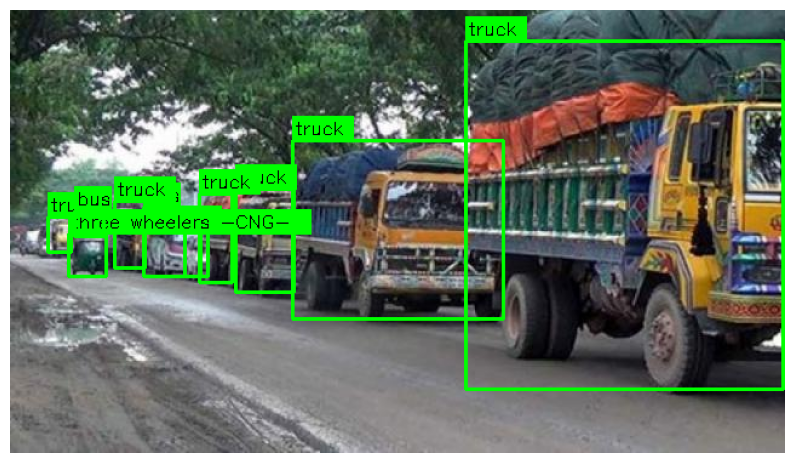

In [2]:
import cv2
import matplotlib.pyplot as plt

# 1. Define your classes exactly as they appear in data_1.yaml
classes = ['ambulance', 'army vehicle', 'auto rickshaw', 'bicycle', 'bus', 'car', 
           'garbagevan', 'human hauler', 'minibus', 'minivan', 'motorbike', 'pickup', 
           'policecar', 'rickshaw', 'scooter', 'suv', 'taxi', 'three wheelers -CNG-', 
           'truck', 'van', 'wheelbarrow']

# 2. Paths to your specific image and matching .txt label file
image_path = r"E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\train\images\06_jpeg.rf.14bdc2005d8029bbe9f24fad4b6af7ea.jpg"
label_path = r"E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\train\labels\06_jpeg.rf.14bdc2005d8029bbe9f24fad4b6af7ea.txt"

# 3. Load image and get its actual pixel dimensions
img = cv2.imread(image_path)
img_height, img_width, _ = img.shape

# 4. Open the YOLO label text file
with open(label_path, 'r') as file:
    for line in file.readlines():
        # YOLO format is: class_id, x_center, y_center, width, height
        class_id, x_c, y_c, w, h = map(float, line.strip().split())
        
        # Get the actual class name string from our list
        class_name = classes[int(class_id)]
        
        # Un-normalize the coordinates (Convert from 0.0-1.0 to Actual Image Pixels)
        xmin = int((x_c - w / 2) * img_width)
        ymin = int((y_c - h / 2) * img_height)
        xmax = int((x_c + w / 2) * img_width)
        ymax = int((y_c + h / 2) * img_height)
        
        # Draw the Bounding Box (Green, thickness=2)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        
        # Draw a filled rectangle behind the text for readability
        cv2.rectangle(img, (xmin, ymin - 20), (xmin + len(class_name)*10, ymin), (0, 255, 0), -1)
        # Draw the class name Text (Black)
        cv2.putText(img, class_name, (xmin + 2, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

# 5. Display the final image with Matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


---
## 5. Initiating Transfer Learning Loop (YOLOv8)

Now that the dataset is structured, we will instantiate a pre-trained **YOLOv8n** model.
The model comes pre-loaded with knowledge about general shapes and patterns. By invoking `.train()`, we erase its generic classification head, replace it with our 21 custom classes, and update the CNN kernels specifically for localized road vehicles!

*(Normally, Object Detection requires dozens of epochs. For educational demonstration speed, we will do a fast pass. Feel free to increase `epochs=50` if running remotely on a GPU system)*

In [3]:
# Load native PyTorch ultralytics configuration
model_yolo = YOLO('yolov8n.pt') 

results = model_yolo.train(
    data=r'E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\data_1.yaml',  # Point direct to our localized file
    epochs=5,               # Increase to 50 for real-world precision
    imgsz=416,              # Safe image tensor sizing
    batch=16,               # Fit memory blocks natively for most GPUs
    project='vehicle_detection', # Folder structure to organize output
    name='custom_model'     # Subfolder name
)


Ultralytics 8.4.41  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1070 with Max-Q Design, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\data_1.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_model-3, 

---
## 6. Validating Predictions on Testing Data

Once the network has completed altering its internal weights, the best state is serialized to disc under: `vehicle_detection/custom_model/weights/best.pt`.

Let's load the model and construct an exclusive visualizer. We will grab an image entirely isolated in the `valid/images/` subset (the AI has *never* seen it), infer predictions, and plot the actual detected boxes vs predictions!


image 1/1 E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\valid\images\Pias--139-_jpg.rf.3480cbf4cd5e0ba990e49896b2a3d9aa.jpg: 256x416 3 cars, 59.2ms
Speed: 2.0ms preprocess, 59.2ms inference, 2.7ms postprocess per image at shape (1, 3, 256, 416)


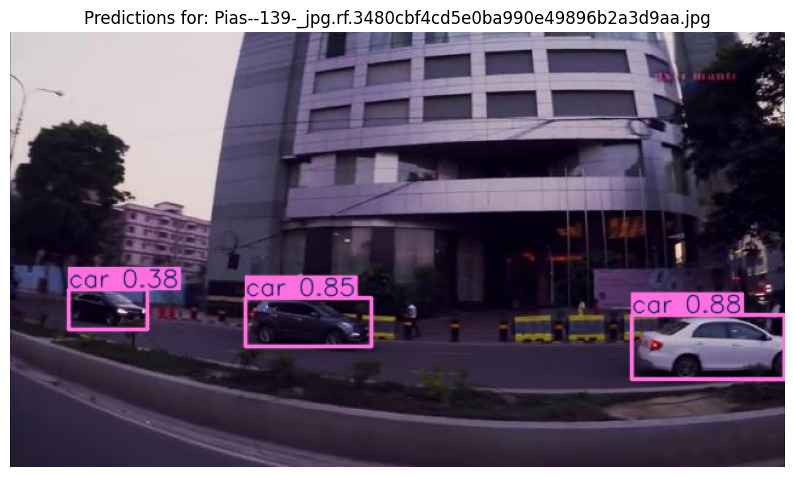


image 1/1 E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\valid\images\Pias--14-_jpg.rf.bc90f7011d8a8519dd9c8eeb3f4a5bce.jpg: 256x416 5 cars, 4 motorbikes, 20.0ms
Speed: 1.8ms preprocess, 20.0ms inference, 4.9ms postprocess per image at shape (1, 3, 256, 416)


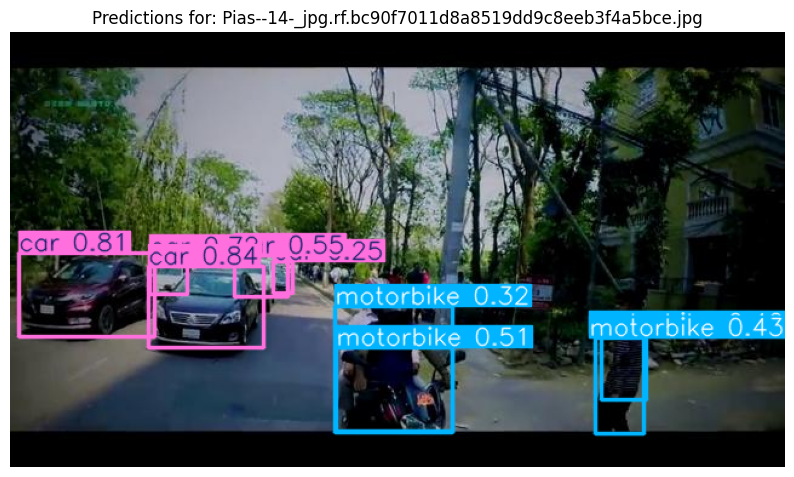


image 1/1 E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\valid\images\Pias--140-_jpg.rf.1fa359c696f211a5fe03f52d0d7c004a.jpg: 256x416 1 bus, 3 cars, 2 motorbikes, 14.2ms
Speed: 2.6ms preprocess, 14.2ms inference, 2.5ms postprocess per image at shape (1, 3, 256, 416)


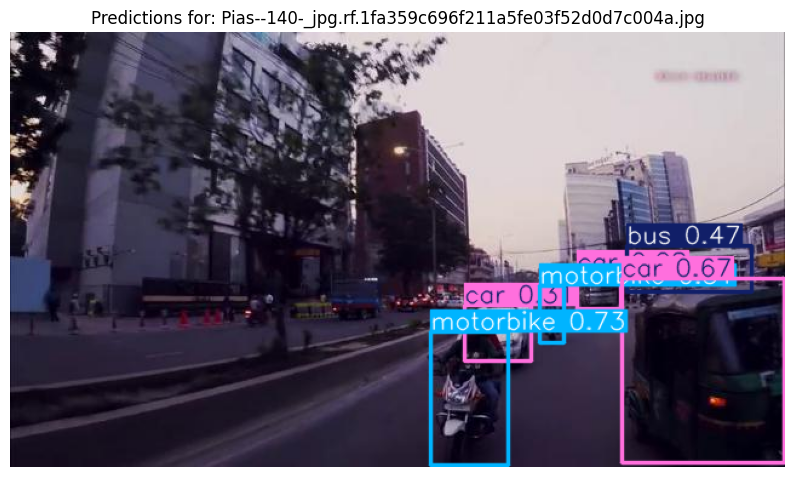


image 1/1 E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\valid\images\Pias--141-_jpg.rf.faba2aa0d33f0cf10d64d508652c2c3d.jpg: 256x416 1 car, 1 motorbike, 15.3ms
Speed: 1.2ms preprocess, 15.3ms inference, 4.3ms postprocess per image at shape (1, 3, 256, 416)


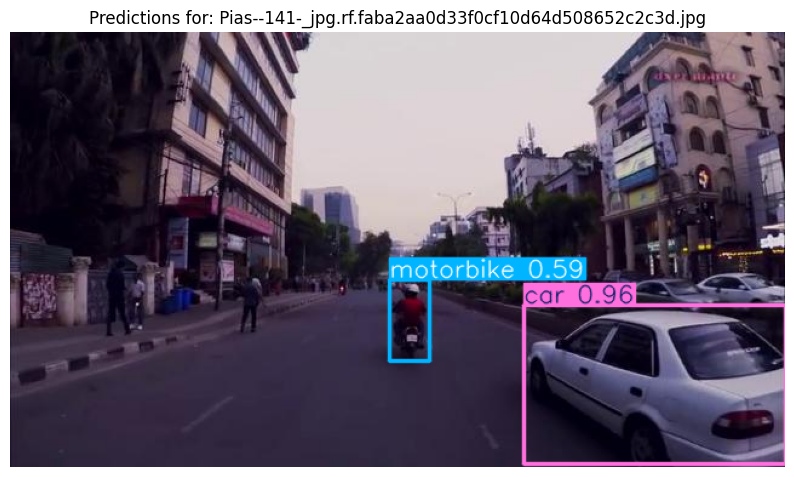


image 1/1 E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\valid\images\Pias--142-_jpg.rf.1f52a77da4d54b26bd0ef1e43c839f03.jpg: 256x416 2 cars, 3 motorbikes, 25.8ms
Speed: 3.2ms preprocess, 25.8ms inference, 5.5ms postprocess per image at shape (1, 3, 256, 416)


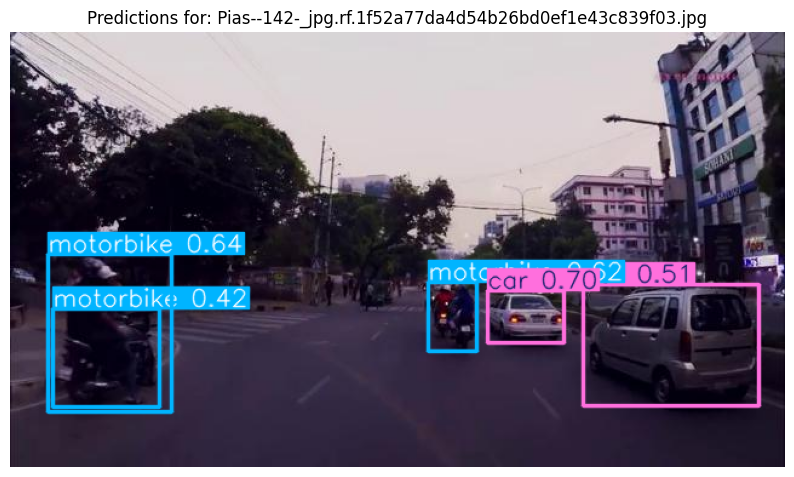

In [4]:

model = YOLO(r'E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\runs\detect\vehicle_detection\custom_model-2\weights\best.pt')
test_images_dir = r"E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\vehicle_dataset\trafic_data\valid\images"

# Get a list of all .jpg images in the folder
all_test_images = glob.glob(test_images_dir + r"\*.jpg")

# Let's loop through just the first 5 images and display them directly in the notebook
for img_path in all_test_images[:5]:
    # Run AI on this specific image
    result = model(img_path)[0]
    
    # Render the AI's predictions (draws the boxes and labels)
    rendered_img = result.plot()
    
    # Display it via Matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(rendered_img[..., ::-1]) # Convert BGR to RGB
    plt.axis('off')
    plt.title(f"Predictions for: {img_path.split(chr(92))[-1]}") # Get file name
    plt.show()


## Lets try on a video

In [5]:
# 2. Path to the video you want to analyze
video_path = r"E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\14225565_1080_1920_30fps.mp4"

# 3. Run prediction! 
# save=True tells YOLO to compile and save the finished video with all boxes drawn.
results = model.predict(source=video_path, save=True, conf=0.5)




WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1297) E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\14225565_1080_1920_30fps.mp4: 416x256 7 motorbikes, 56.3ms
video 1/1 (frame 2/1297) E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\14225565_1080_1920_30fps.mp4: 416x256 8 motorbikes, 43.5ms
video 1/1 (frame 3/1297) E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\14225565_1080_1920_30fps.mp4: 416x256 8 motorbikes, 24.6ms
video 1/1 (frame 4/1297) E:\NAVTTC-AI-Course\Month 02\Week 08\Notebo

---
## Conclusion!

In this end-to-end curriculum on applied computer vision, we completed a **production-scale object detection pipeline**!

We sourced completely custom imagery for specialized regional road traffic configurations, mapped YOLO's rigid multi-dimensional format onto dynamic variables, isolated underlying mathematical structures to plot Ground Truth borders manually, and then subjected YOLOv8 to custom Transfer Learning manipulation!